In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
%load_ext autoreload
%autoreload 2
from Grape import GrapeLBFGS as gp

In [2]:
Nc = 6          # cavity dim: levels 0...Nc-1 only for unitary target via projection
Nq = 2          # qubit dim: levels 0...Nq-1 only for unitary target via projection
Nc_big = 12     # total cavity dim: includes higher levels
Nq_big = 5      # total qubit dim: includes higher levels

g = 1.0 * 2*np.pi        # coupling (angular units)
alpha = -160.0 * 2*np.pi # transmon anharmonicity (angular units)

def sigmaz_01(Nq: int) -> qt.Qobj:
    """
    σz acting on the computational transmon subspace {|0>,|1>},
    embedded in an Nq-level truncation:
      diag = [+1, -1, 0, 0, ...]
    """
    d = np.zeros(Nq, dtype=float)
    d[0] = +1.0
    d[1] = -1.0
    return qt.Qobj(np.diag(d))

def make_H(Nc: int, Nq: int, g: float, alpha: float) -> tuple[qt.Qobj, qt.Qobj]:
    """
    Build drift and control Hamiltonians for detuning control:

      H(t) = H_d + Δ(t) * H_c

    where:
      - H_d contains JC exchange + transmon Kerr anharmonicity
      - H_c is the transmon number operator n_q = a_q† a_q
    Tensor order: cavity ⊗ transmon.

    Returns:
      H_d, H_c
    """
    a_r = qt.tensor(qt.destroy(Nc), qt.qeye(Nq))   # cavity lowering
    a_q = qt.tensor(qt.qeye(Nc), qt.destroy(Nq))   # transmon lowering
    n_q = a_q.dag() * a_q

    H_d = g * (a_q.dag()*a_r + a_q*a_r.dag())
    H_d += (alpha/2.0) * (a_q.dag()*a_q.dag()*a_q*a_q)

    H_c = n_q
    return H_d, H_c

def target_controlled_parity(Nc: int, Nq: int) -> qt.Qobj:
    """
    Controlled-parity mapping gate (Ramsey-style):

      U_target = exp( -i (π/2) * n_cavity * σz^(01) )

    n_cavity acts on cavity, σz^(01) acts on transmon |0>,|1>.
    """
    n_r = qt.tensor(qt.num(Nc), qt.qeye(Nq))
    sz = qt.tensor(qt.qeye(Nc), sigmaz_01(Nq))
    return (-1j * (np.pi/2.0) * (n_r * sz)).expm()

def small_space_projector(Nc_big: int, Nq_big: int, Nc: int, Nq: int) -> qt.Qobj:
    """
    BIG-space projector P (dimension Nc_big*Nq_big) that projects onto the
    subspace spanned by |n_cav>⊗|q> with:
        n_cav = 0..Nc-1,  q = 0..Nq-1

    Tensor order: cavity ⊗ qubit/transmon.
    """
    if not (0 <= Nc <= Nc_big and 0 <= Nq <= Nq_big):
        raise ValueError("Need 0 <= Nc <= Nc_big and 0 <= Nq <= Nq_big")
    
    diag = np.array([1]*Nc + [0]*(Nc_big - Nc), dtype=float)
    Pc = qt.Qobj(np.diag(diag), dims=[[Nc_big], [Nc_big]])

    diag = np.array([1]*Nq + [0]*(Nq_big - Nq), dtype=float)
    Pq = qt.Qobj(np.diag(diag), dims=[[Nq_big], [Nq_big]])

    # Full projector on big tensor space
    P = qt.tensor(Pc, Pq)  # (Nc_big*Nq_big) x (Nc_big*Nq_big)
    return P


In [4]:
dt = 0.05
n_steps = 40
det_min = -300 * 2*np.pi
det_max = 300 * 2*np.pi

a_r = qt.tensor(qt.destroy(Nc_big), qt.qeye(Nq_big))   # cavity lowering
a_q = qt.tensor(qt.qeye(Nc_big), qt.destroy(Nq_big))   # transmon lowering

opt = gp(
    H_drift = 0*a_q.dag()*a_q,  # no drift
    H_controls = [a_r.dag()*a_r*qt.tensor(qt.qeye(Nc_big), sigmaz_01(Nq_big))],  # dispersive interaction
    U_target = target_controlled_parity(Nc_big, Nq_big),
    dt = dt,
    n_steps = n_steps,
    cost_type= "projected",
    projector = small_space_projector(Nc_big, Nq_big, Nc, Nq),
    derivative= "frechet"
)

opt.add_l2_amplitude_penalty(lam=1e-1)                          # discourage huge amplitudes
opt.add_smoothness_penalty(lam=1e-1)                            # encourage smooth pulses

# Random initial pulse in [det_min, det_max], shape (n_steps, 1)
pulses0 = np.pi*np.ones((n_steps, 1))/(2*dt*n_steps) 

out = opt.optimize(
    maxiter=200,
    pulse_bounds=[(det_min, det_max)],
    pulses0=pulses0,
)


Fidelity: 1.0
Fidelity: 1.0
Fidelity: 0.9977403213048603
Fidelity: 0.9977403213048603
Fidelity: 0.9977403213048603
Fidelity: 0.999332066064505
Fidelity: 0.999332066064505
Fidelity: 0.999332066064505
Fidelity: 0.9993338126077492
Fidelity: 0.9993338126077492
Fidelity: 0.9993338126077492


Fidelity: 0.9993338126077492
Final fidelity: 0.9993338126077492


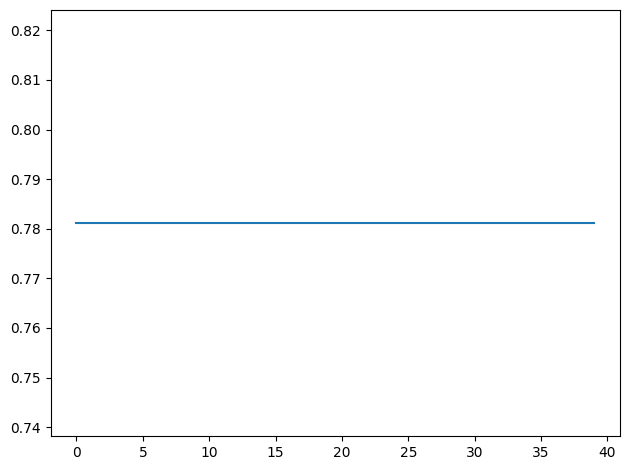

In [5]:
# Print final fidelity achieved
print("Final fidelity:", opt.fidelity(out["pulses_opt"]))

# Plot resulting pulses
plt.figure()
plt.plot(np.arange(n_steps), out["pulses_opt"][:,0])
plt.tight_layout()
plt.show()

In [6]:
print(dt*n_steps*out["pulses_opt"][0,0])
print(np.pi/2)

1.5622701943524864
1.5707963267948966


In [7]:
dt = 0.05
n_steps = 40
det_min = -3000 * 2*np.pi
det_max = 3000 * 2*np.pi

a_r = qt.tensor(qt.destroy(Nc_big), qt.qeye(Nq_big))   # cavity lowering
a_q = qt.tensor(qt.qeye(Nc_big), qt.destroy(Nq_big))   # transmon lowering

opt = gp(
    H_drift = 0*a_q.dag()*a_q,  # no drift
    H_controls = [a_r.dag()*a_r*a_q.dag()*a_q],  # dispersive interaction
    U_target = target_controlled_parity(Nc_big, Nq_big),
    dt = dt,
    n_steps = n_steps,
    cost_type= "projected",
    projector = small_space_projector(Nc_big, Nq_big, Nc, Nq),
    derivative= "frechet",
    gauge_ops=[qt.tensor(qt.num(Nc_big), qt.qeye(Nq_big))]
)

# opt.add_l2_amplitude_penalty(lam=1e-3)                          # discourage huge amplitudes
opt.add_smoothness_penalty(lam=1e-2)                            # encourage smooth pulses

# Random initial pulse| in [det_min, det_max], shape (n_steps, 1)
pulses0 = np.pi*np.ones((n_steps, 1))/(dt*n_steps) 
pulses0 += 0.1 * np.random.randn(n_steps, 1)

out = opt.optimize(
    maxiter=200,
    pulse_bounds=[(det_min, det_max)],
    pulses0=pulses0,
    theta0 = [-np.pi/3]
)

Fidelity: 0.39899295756231035
Fidelity: 0.39899295756231035
Fidelity: 0.4845237057174249
Fidelity: 0.4845237057174249
Fidelity: 0.9959312422918196
Fidelity: 0.9959312422918196
Fidelity: 0.9959312422918196
Fidelity: 0.9942200839940953
Fidelity: 0.9942200839940953
Fidelity: 0.9998978762738453
Fidelity: 0.9998978762738453
Fidelity: 0.9998978762738453
Fidelity: 0.9999129933103682
Fidelity: 0.9999129933103682
Fidelity: 0.9999610226179715
Fidelity: 0.9999610226179715
Fidelity: 0.9999540932248353
Fidelity: 0.9999540932248353
Fidelity: 0.9999540932248353
Fidelity: 0.9995912293568369
Fidelity: 0.9995912293568369
Fidelity: 0.9995912293568369
Fidelity: 0.9999157554827117
Fidelity: 0.9999157554827117
Fidelity: 0.9999157554827117
Fidelity: 0.9999943790229044
Fidelity: 0.9999943790229044
Fidelity: 0.9999943790229044
Fidelity: 0.99999996425465
Fidelity: 0.99999996425465
Fidelity: 0.99999996425465
Fidelity: 0.9999892736634237
Fidelity: 0.9999892736634237
Fidelity: 0.9999892736634237
Fidelity: 0.999993

Fidelity: 0.9999999999828891
Final fidelity: 0.9999999999828891


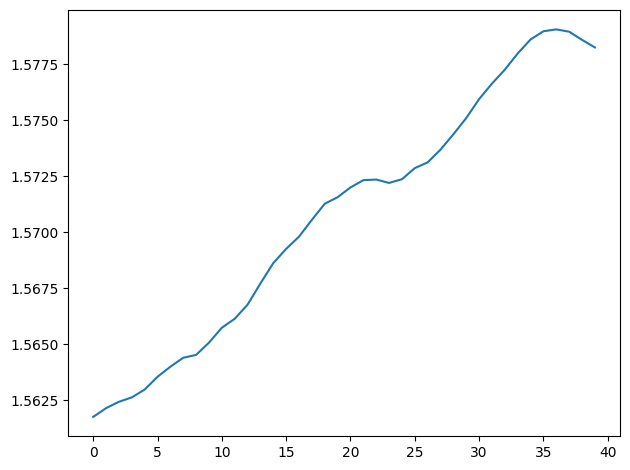

In [8]:
# Print final fidelity achieved
print("Final fidelity:", opt.fidelity(out["pulses_opt"], theta=out["theta_opt"]))

# Plot resulting pulses
plt.figure()
plt.plot(np.arange(n_steps), out["pulses_opt"][:,0])
plt.tight_layout()
plt.show()

In [9]:
print(dt*n_steps*out["pulses_opt"][0,0])
print(np.pi)

3.123535395441328
3.141592653589793


In [11]:
Nc = 6          # cavity dim: levels 0...Nc-1 only for unitary target via projection
Nq = 2          # qubit dim: levels 0...Nq-1 only for unitary target via projection
Nc_big = 12     # total cavity dim: includes higher levels
Nq_big = 5      # total qubit dim: includes higher levels

a_r = qt.tensor(qt.destroy(Nc_big), qt.qeye(Nq_big))   # cavity lowering
a_q = qt.tensor(qt.qeye(Nc_big), qt.destroy(Nq_big))   # transmon lowering

n_r = qt.tensor(qt.num(Nc_big), qt.qeye(Nq_big))
n_q = qt.tensor(qt.qeye(Nc_big), qt.num(Nq_big))

U_cross = (-1j * np.pi * (n_r * n_q)).expm()              # this is the cross-Kerr needed
U_cp_reconstructed = (-1j * (np.pi/2) * n_r).expm() * U_cross
U_cp = target_controlled_parity(Nc_big, Nq_big)

P = small_space_projector(Nc_big, Nq_big, Nc, Nq)
d = Nc*Nq

F = abs((U_cp.dag() * U_cp_reconstructed*P).tr())**2 / d**2
print("F:", F)   # should be ~1 (numerically)

F: 1.0
